# День 1 — Загрузка датасета и первичный анализ

**Цель:** загрузить финансовые тексты с размеченной тональностью, проверить качество данных и понять структуру будущей задачи классификации.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

from finnews_sentiment.data.load_data import (
    DEFAULT_CONFIG,
    load_financial_phrasebank,
    save_processed,
)
from finnews_sentiment.visualization import (
    plot_class_distribution,
    plot_text_length_distribution,
)

pd.set_option("display.max_colwidth", 120)

## 1. Конфигурация

Используем Financial PhraseBank в конфигурации `sentences_75agree`: в неё входят предложения, для которых не менее 75% разметчиков согласились с классом.

In [2]:
current_dir = Path.cwd().resolve()
PROJECT_ROOT = current_dir if (current_dir / "pyproject.toml").exists() else current_dir.parent
assert (PROJECT_ROOT / "pyproject.toml").exists(), "Запустите ноутбук из корня проекта или каталога notebooks"

DATASET_CONFIG = DEFAULT_CONFIG
DATA_PATH = PROJECT_ROOT / "data/raw/financial_phrasebank_75agree.csv"
REPORT_DIR = PROJECT_ROOT / "reports/day01"
CLASS_ORDER = ["negative", "neutral", "positive"]
REPORT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Загрузка данных

Внутренняя функция проекта загружает официальный архив с Hugging Face, выбирает нужную конфигурацию и возвращает единую схему `text, sentiment`. Исходные тексты на этом этапе не очищаются.

In [3]:
df = load_financial_phrasebank(DATASET_CONFIG)
save_processed(df, DATA_PATH)

print(f"Датасет сохранён: {DATA_PATH.relative_to(PROJECT_ROOT)}")
print(f"Размер: {df.shape[0]} строк × {df.shape[1]} столбца")
display(df.head())

Датасет сохранён: data/raw/financial_phrasebank_75agree.csv
Размер: 3453 строк × 2 столбца


,text,sentiment
0,"According to Gran , the company has no plans to move all production to Russia , although that is where the company i...",neutral
1,With the new production plant the company would increase its capacity to meet the expected increase in demand and wo...,positive
2,"For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year ear...",positive
3,"In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR ...",positive
4,Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007 representing 7.7 % of net s...,positive


## 3. Схема и качество данных

In [4]:
schema = pd.DataFrame({
    "Тип": df.dtypes.astype(str),
    "Пропуски": df.isna().sum(),
})
empty_texts = df["text"].fillna("").str.strip().eq("").sum()
duplicate_rows = df.duplicated().sum()

display(schema)
print(f"Пустых текстов: {empty_texts}")
print(f"Полных дублей строк: {duplicate_rows}")

,Тип,Пропуски
text,string,0
sentiment,string,0


Пустых текстов: 0
Полных дублей строк: 5


## 4. Распределение классов

,Количество,"Доля, %"
sentiment,,
negative,420,12.16
neutral,2146,62.15
positive,887,25.69


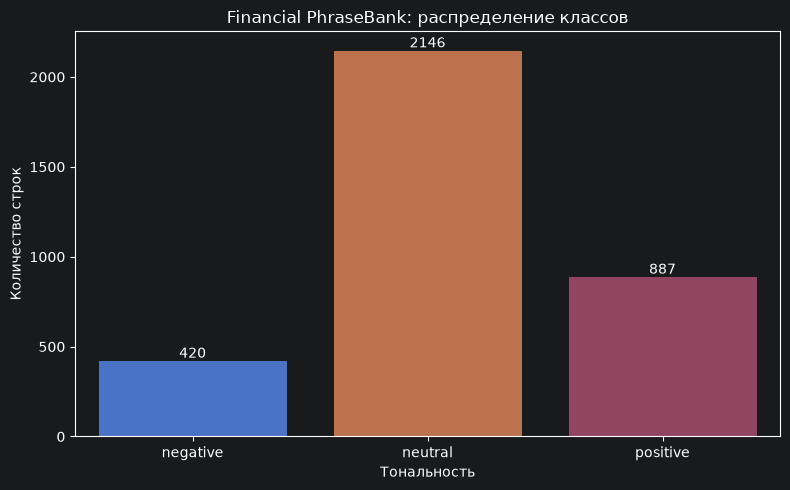

In [5]:
class_counts = df["sentiment"].value_counts().reindex(CLASS_ORDER)
class_distribution = pd.DataFrame({
    "Количество": class_counts,
    "Доля, %": (class_counts / len(df) * 100).round(2),
})
display(class_distribution)

class_figure = plot_class_distribution(
    class_counts,
    output_path=REPORT_DIR / "class_distribution.png",
)

Классы несбалансированы: нейтральных примеров существенно больше. Поэтому на этапе обучения понадобится стратифицированное разбиение, а основной метрикой лучше выбрать macro F1.

## 5. Длины текстов

In [6]:
lengths = pd.DataFrame({
    "Символы": df["text"].str.len(),
    "Слова": df["text"].str.split().str.len(),
})
length_summary = (
    lengths.describe(percentiles=[0.5, 0.95])
    .loc[["min", "50%", "mean", "95%", "max"]]
    .rename(index={"min": "Минимум", "50%": "Медиана", "mean": "Среднее", "95%": "P95", "max": "Максимум"})
    .round(2)
)
display(length_summary)

,Символы,Слова
Минимум,9.0,2.00
Медиана,116.0,21.00
Среднее,124.86,22.76
P95,231.0,42.40
Максимум,315.0,81.00


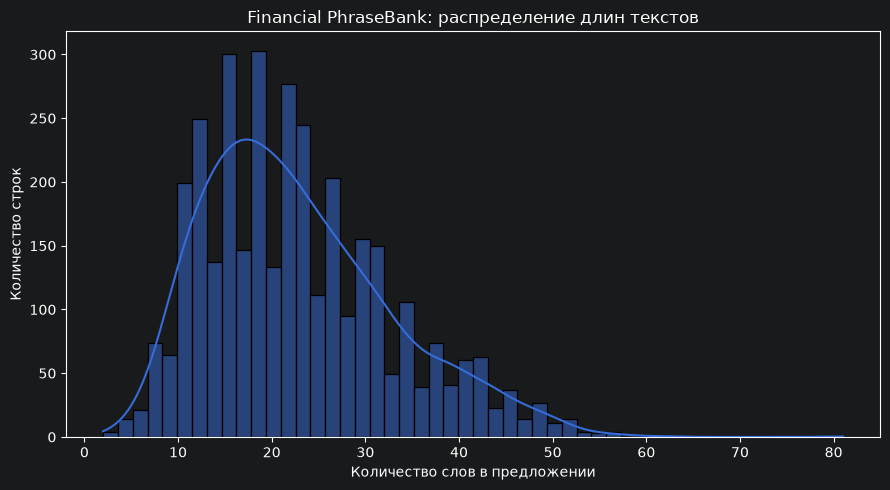

In [7]:
length_figure = plot_text_length_distribution(
    lengths["Слова"],
    output_path=REPORT_DIR / "text_length_distribution.png",
)

## 6. Примеры классов

In [9]:
examples = (
    df.groupby("sentiment", sort=False)["text"]
    .first()
    .reindex(CLASS_ORDER)
    .rename("Пример текста")
    .to_frame()
)
display(examples)

,Пример текста
sentiment,
negative,"Jan. 6 -- Ford is struggling in the face of slowing truck and SUV sales and a surfeit of up-to-date , gotta-have cars ."
neutral,"According to Gran , the company has no plans to move all production to Russia , although that is where the company i..."
positive,With the new production plant the company would increase its capacity to meet the expected increase in demand and wo...


## 7. Первые выводы

In [10]:
majority_class = class_counts.idxmax()
majority_share = class_distribution.loc[majority_class, "Доля, %"]
median_words = length_summary.loc["Медиана", "Слова"]
p95_words = length_summary.loc["P95", "Слова"]

display(Markdown(f"""
- Датасет содержит **{len(df)}** финансовых предложений и три класса тональности.
- Пропусков и пустых текстов нет; обнаружено **{duplicate_rows}** полных дублей, решение об их удалении относится к дню 2.
- Преобладает класс **{majority_class}** — **{majority_share:.2f}%** примеров.
- Медианная длина текста — **{median_words:.0f} слово**, а 95% текстов не длиннее **{p95_words:.1f} слова**.
- Для будущей оценки модели используем стратифицированное разбиение и macro F1.
"""))


- Датасет содержит **3453** финансовых предложений и три класса тональности.
- Пропусков и пустых текстов нет; обнаружено **5** полных дублей, решение об их удалении относится к дню 2.
- Преобладает класс **neutral** — **62.15%** примеров.
- Медианная длина текста — **21 слово**, а 95% текстов не длиннее **42.4 слова**.
- Для будущей оценки модели используем стратифицированное разбиение и macro F1.
